In [1]:
%cd ..

/home/eli/AnacondaProjects/wgvp_pc


In [2]:
import hydra
import math
import matplotlib.pyplot as plt
import jax
import numpy as np
import numpyro
from omegaconf import OmegaConf
import rootutils
import sys

In [3]:
from src import test, train

In [4]:
with hydra.initialize(version_base="1.3", config_path="../configs", job_name="eval"):
    cfg = hydra.compose(config_name="eval.yaml", overrides=["ckpt_path=logs/train/runs/2025-12-02_11-48-14/saved/checkpoint-epoch250.npy",
                                                            "+experiment=generator_pgd", "hydra.runtime.output_dir=logs/test"], return_hydra_config=True)
    hydra.core.hydra_config.HydraConfig.instance().set_config(cfg)
    metrics, objects = test.test(cfg)

In [5]:
metrics

{'loss': np.float32(53595.938), 'log_w': np.float32(-53595.934)}

In [6]:
for data, target, indices in objects['datamodule'].valid_dataloader():
    recons = objects['monad'](data, indices, stage="valid")['obs'].squeeze().mean(axis=0).reshape(data.shape[0], 1, 28, 28)
    break

/home/eli/AnacondaProjects/wgvp_pc/src/inference/graphical.py:52: UserWarning: Found vars in model but not guide: {'obs'}
  check_model_guide_match(model_trace, guide_trace)


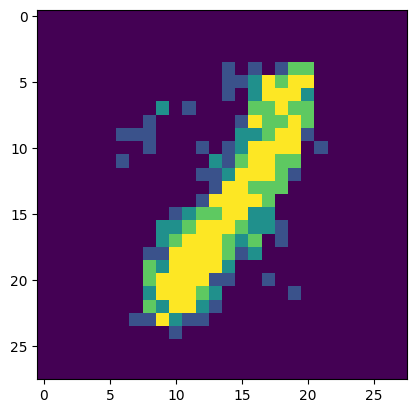

In [7]:
plt.imshow(recons[1].squeeze())

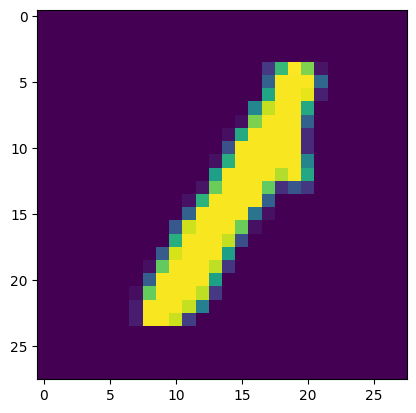

In [8]:
plt.imshow(data[1].squeeze())